# ***Juntar excel's (1993-2018) con (2018-2025)***

In [ ]:
import pandas as pd
from openpyxl import load_workbook

def read_excel_values_only(path):
    wb = load_workbook(path, data_only=True)
    ws = wb.active

    rows = []
    for row in ws.iter_rows(values_only=True):
        rows.append(list(row))
    df = pd.DataFrame(rows[1:], columns=rows[0])
    return df

file1 = "G (JUNIO 93 - FEBRERO 18).xlsx"
file2 = "G (MARZO 18 - NOVIEMBRE 25).xlsx"

df1 = read_excel_values_only(file1)
df2 = read_excel_values_only(file2)
df2 = df2.rename(columns={
    "FECHA - HORA UTC": "FECHA_HORA",
    "LATITUD (°)": "LATITUD (grados)",
    "LONGITUD (°)": "LONGITUD (grados)",
    "PROF. (Km)": "PROFUNDIDAD (Km)",
    "MAGNITUD": "MAGNITUD Ml",
    "TIPO MAGNITUD": "MAGNITUD Mw",
    "FASES": "# FASES",
    "GAP (°)": "GAP (grados)",
    "REGION": "DEPARTAMENTO"
})

if "FECHA_HORA" in df2.columns:
    fecha_split = df2["FECHA_HORA"].astype(str).str.split(pat=" ", n=1, expand=True)
    df2["FECHA"] = fecha_split[0]
    df2["HORA_UTC"] = fecha_split[1]
    df2.drop(columns=["FECHA_HORA"], inplace=True)
columnas_comunes = list(set(df1.columns).intersection(set(df2.columns)))

df1_c = df1[columnas_comunes]
df2_c = df2[columnas_comunes]
df_final = pd.concat([df1_c, df2_c], ignore_index=True)

output = "G_UNIFICADO_COLUMNAS_COMUNES.xlsx"
df_final.to_excel(output, index=False)

print("Archivo generado:", output)
print("Columnas comunes:", columnas_comunes)


Archivo generado: G_UNIFICADO_COLUMNAS_COMUNES.xlsx
Columnas comunes: ['PROFUNDIDAD (Km)', 'ERROR LONGITUD (Km)', 'ERROR LATITUD (Km)', 'MAGNITUD Ml', 'FECHA', 'HORA_UTC', 'GAP (grados)', 'MAGNITUD Mw', 'ESTADO', 'LATITUD (grados)', 'LONGITUD (grados)', 'DEPARTAMENTO', 'RMS (Seg)', '# FASES', 'ERROR PROFUNDIDAD (Km)']


# ***Frecuencia mensual de sismos***

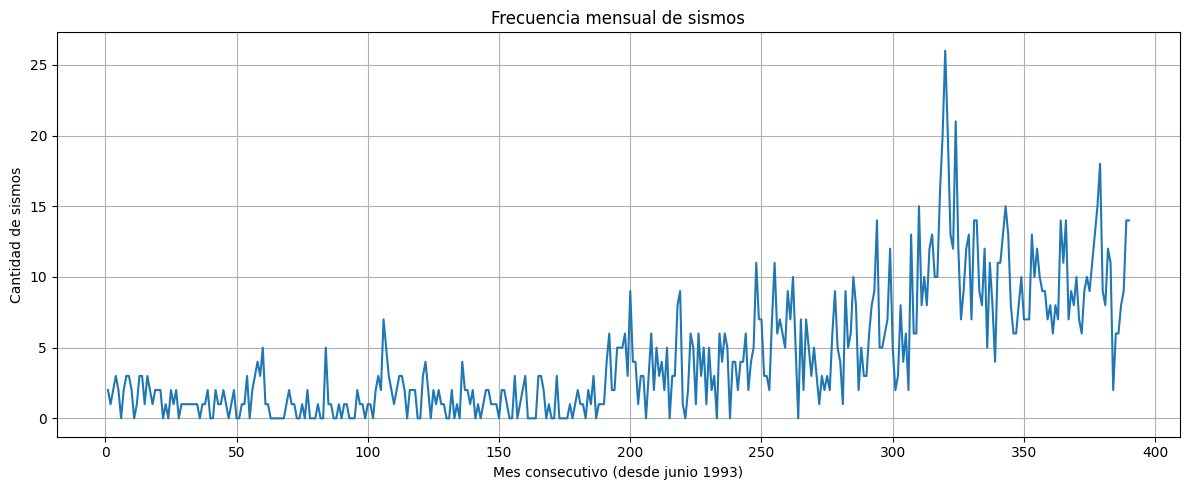

Excel generado: SISMOS_POR_MES_ZONA_G.xlsx


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("G_UNIFICADO_COLUMNAS_COMUNES.xlsx")

df["FECHA"] = pd.to_datetime(df["FECHA"], errors="coerce")
df = df.dropna(subset=["FECHA"])
fecha_inicio = pd.to_datetime("1993-06-01")
df = df[df["FECHA"] >= fecha_inicio].copy()
df = df.sort_values("FECHA")
df["MES"] = ((df["FECHA"].dt.year - fecha_inicio.year) * 12 +
             (df["FECHA"].dt.month - fecha_inicio.month) + 1).astype(int)

conteo = df.groupby("MES").size().reset_index(name="CANTIDAD_SISMOS")

mes_max = conteo["MES"].max() if not conteo.empty else 1
todos_los_meses = pd.DataFrame({"MES": range(1, mes_max + 1)})
conteo_completo = todos_los_meses.merge(conteo, on="MES", how="left")
conteo_completo["CANTIDAD_SISMOS"] = conteo_completo["CANTIDAD_SISMOS"].fillna(0).astype(int)

conteo_completo["AÑO"] = fecha_inicio.year + (conteo_completo["MES"] - 1) // 12
conteo_completo["MES_REAL"] = ((conteo_completo["MES"] - 1 + 5) % 12) + 1

conteo_completo["ETIQUETA"] = (
    conteo_completo["AÑO"].astype(str) + "-" +
    conteo_completo["MES_REAL"].astype(str).str.zfill(2)
)

salida = "SISMOS_POR_MES_ZONA_G.xlsx"
conteo_completo.to_excel(salida, index=False)
plt.figure(figsize=(12, 5))
plt.plot(conteo_completo["MES"], conteo_completo["CANTIDAD_SISMOS"])
plt.xlabel("Mes consecutivo (desde junio 1993)")
plt.ylabel("Cantidad de sismos")
plt.title("Frecuencia mensual de sismos")
plt.grid(True)
plt.tight_layout()

plt.savefig("grafica_sismos_Zona_G.png", dpi=300)
plt.show()
print("Excel generado:", salida)


# ***Frecuencia de sismos por mes y año***



Ingrese el mes (1-12): 8
Ingrese el año (1993 - 2025): 2009
1     0
2     0
3     0
4     0
5     0
6     0
7     1
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    1
26    0
27    0
28    0
29    0
30    0
31    0
dtype: int64
La suma da:  2
Archivo Excel guardado como: frecuencia_sismos_2009_08.xlsx


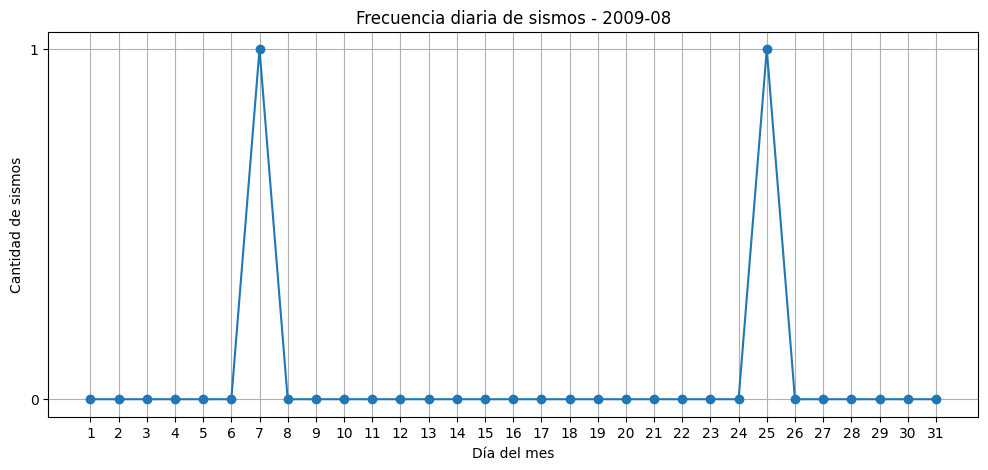

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import calendar
from matplotlib.ticker import MaxNLocator

df = pd.read_excel("D_UNIFICADO_COLUMNAS_COMUNES.xlsx")
df["FECHA"] = pd.to_datetime(df["FECHA"])

def graficar_frecuencia_por_dia(mes, año):
    dias_en_mes = calendar.monthrange(año, mes)[1]
    datos = df[(df["FECHA"].dt.year == año) & (df["FECHA"].dt.month == mes)]
    frecuencia = datos.groupby(datos["FECHA"].dt.day).size()
    dias = pd.Series(0, index=range(1, dias_en_mes + 1))
    for dia, valor in frecuencia.items():
        dias[dia] = valor
    print(dias)
    suma = 0
    for i in range(1, dias_en_mes + 1):
        suma += dias[i]
    print('La suma da: ', suma)

    df_excel = dias.reset_index()
    df_excel.columns = ["Día", "Cantidad de sismos"]
    nombre_archivo = f"frecuencia_sismos_{año}_{mes:02d}.xlsx"
    df_excel.to_excel(nombre_archivo, index=False)

    print(f"Archivo Excel guardado como: {nombre_archivo}")
    plt.figure(figsize=(12, 5))
    plt.plot(dias.index, dias.values, marker='o')
    plt.title(f"Frecuencia diaria de sismos - {año}-{mes:02d}")
    plt.xlabel("Día del mes")
    plt.ylabel("Cantidad de sismos")
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid(True)
    plt.xticks(range(1, dias_en_mes + 1))
    plt.show()

mes = int(input('Ingrese el mes (1-12): '))
año = int(input('Ingrese el año (1993 - 2025): '))
graficar_frecuencia_por_dia(mes, año)


# ***Omori***

/tmp/ipykernel_2379/3505806921.py:24: RuntimeWarning: invalid value encountered in power
  return k / (c + t)**p


Parámetros ajustados:
k = 8.0974
c = 0.9941
p = 1.2190


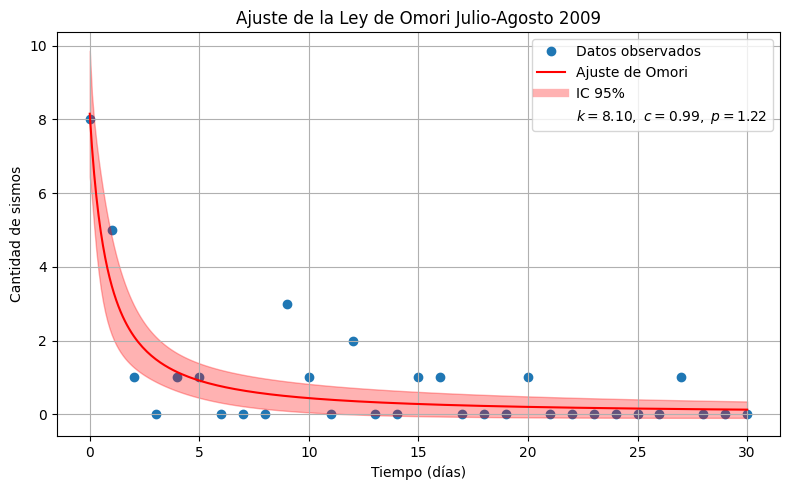

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import t
from matplotlib.lines import Line2D

data = pd.read_excel(
    'Sismo_JulioAgosto_2009.xlsx',
    header=None,
    skiprows=1
)

tseg = data.iloc[:, 0].values
Nt   = data.iloc[:, 1].values
def omori(t, k, c, p):
    return k / (c + t)**p
start_point = [1, 10, 0.9]

params, cov = curve_fit(
    omori,
    tseg,
    Nt,
    p0=start_point,
    maxfev=50000
)

k, c, p = params

print("Parámetros ajustados:")
print(f"k = {k:.4f}")
print(f"c = {c:.4f}")
print(f"p = {p:.4f}")

t_fit = np.linspace(tseg.min(), tseg.max(), 300)
Nt_fit = omori(t_fit, k, c, p)
n = len(Nt)
m = len(params)
dof = max(0, n - m)

tval = t.ppf(0.975, dof)

J = np.zeros((len(t_fit), m))
J[:, 0] = 1 / (c + t_fit)**p
J[:, 1] = -k * p / (c + t_fit)**(p + 1)
J[:, 2] = -k * np.log(c + t_fit) / (c + t_fit)**p

var_fit = np.sum(J @ cov * J, axis=1)
sigma_fit = np.sqrt(var_fit)

upper = Nt_fit + tval * sigma_fit
lower = Nt_fit - tval * sigma_fit
plt.figure(figsize=(8, 5))

plt.scatter(tseg, Nt, label='Datos observados')
plt.plot(t_fit, Nt_fit, color='red', label='Ajuste de Omori')

plt.fill_between(
    t_fit, lower, upper,
    color='red', alpha=0.3,
    label='IC 95%'
)

plt.title('Ajuste de la Ley de Omori Julio-Agosto 2009')
plt.xlabel('Tiempo (días)')
plt.ylabel('Cantidad de sismos')
plt.grid(True)
legend_elements = [
    Line2D([0], [0], marker='o', linestyle='None', label='Datos observados'),
    Line2D([0], [0], color='red', label='Ajuste de Omori'),
    Line2D([0], [0], color='red', lw=6, alpha=0.3, label='IC 95%'),
    Line2D([0], [0], linestyle='None',
           label=rf'$k={k:.2f},\ c={c:.2f},\ p={p:.2f}$')
]

plt.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.savefig("grafica_Omori_Julio_Agosto_2009.png", dpi=300)
plt.show()


# ***G-T***

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel("ml_reloc.xlsx")

col = "ml"
df_grp = (
    df.groupby(col)
      .size()
      .reset_index(name="conteo")
      .sort_values(col)
      .reset_index(drop=True)
)

df_grp["N<"] = df_grp["conteo"].cumsum()

total = df_grp["conteo"].sum()  # 70029

df_grp["N>"] = total - df_grp["N<"]

df_grp["log10_N>"] = np.log10(df_grp["N>"])

df_grp.to_excel("GT_ml_reloc.xlsx", index=False)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel("DFechasml.xlsx")

col_mag = "MAGNITUD Ml"
col_fecha = "FECHA"
df[col_fecha] = pd.to_datetime(df[col_fecha])

dia_i = 3
mes_i = 7
anio_i = 2009
dia_f = 3
mes_f = 8
anio_f = 2009

fecha_inicio = pd.Timestamp(anio_i, mes_i, dia_i)
fecha_fin = pd.Timestamp(anio_f, mes_f, dia_f)
df_filtrado = df[
    (df[col_fecha] >= fecha_inicio) &
    (df[col_fecha] <= fecha_fin)
]

df_filtrado = df_filtrado.sort_values(col_mag)
df_grp = (
    df_filtrado
        .groupby(col_mag)
        .size()
        .reset_index(name="conteo")
        .sort_values(col_mag)
        .reset_index(drop=True)
)

df_grp["N<"] = df_grp["conteo"].cumsum()

total = df_grp["conteo"].sum()

df_grp["N>"] = total - df_grp["N<"]

df_grp["log10_N>"] = np.log10(df_grp["N>"])

nombre_archivo = (
    f"Dresultado_magnitudes_"
    f"{anio_i}-{mes_i:02d}-{dia_i:02d}_"
    f"{anio_f}-{mes_f:02d}-{dia_f:02d}.xlsx"
)

df_grp.to_excel(nombre_archivo, index=False)



/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
